# DNN Linear Regression – Housing Price Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


This block imports the libraries needed for the project. Pandas and NumPy are used for data handling, Matplotlib and Seaborn are used for visualization, Scikit-learn is used for preprocessing and evaluation, and TensorFlow/Keras is used to build and train the deep neural network.

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Housing-1.csv")
print("Shape:", df.shape)
df.head()

Saving Housing-1.csv to Housing-1.csv
Shape: (545, 6)


,area,bedrooms,bathrooms,stories,parking,price
0,7420,4,2,3,2,13300000
1,8960,4,4,4,3,12250000
2,9960,3,2,2,2,12250000
3,7500,4,2,2,3,12215000
4,7420,4,1,2,2,11410000


This block uploads the dataset into Google Colab and loads it into a pandas DataFrame. The shape of the dataset is displayed to show the number of rows and columns, and the first few rows are printed to preview the data.

In [3]:
print(df.info())
print("\nMissing values per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   area       545 non-null    int64
 1   bedrooms   545 non-null    int64
 2   bathrooms  545 non-null    int64
 3   stories    545 non-null    int64
 4   parking    545 non-null    int64
 5   price      545 non-null    int64
dtypes: int64(6)
memory usage: 25.7 KB
None

Missing values per column:
 area         0
bedrooms     0
bathrooms    0
stories      0
parking      0
price        0
dtype: int64

Duplicate rows: 1


,area,bedrooms,bathrooms,stories,parking,price
count,545.000000,545.000000,545.000000,545.000000,545.000000,5.450000e+02
mean,5150.541284,2.965138,1.286239,1.805505,0.693578,4.766729e+06
std,2170.141023,0.738064,0.502470,0.867492,0.861586,1.870440e+06
min,1650.000000,1.000000,1.000000,1.000000,0.000000,1.750000e+06
25%,3600.000000,2.000000,1.000000,1.000000,0.000000,3.430000e+06
50%,4600.000000,3.000000,1.000000,2.000000,0.000000,4.340000e+06
75%,6360.000000,3.000000,2.000000,2.000000,1.000000,5.740000e+06
max,16200.000000,6.000000,4.000000,4.000000,3.000000,1.330000e+07


This block performs basic data validation and exploration. It checks the data types, missing values, duplicate rows, and descriptive statistics to better understand the structure and quality of the dataset.

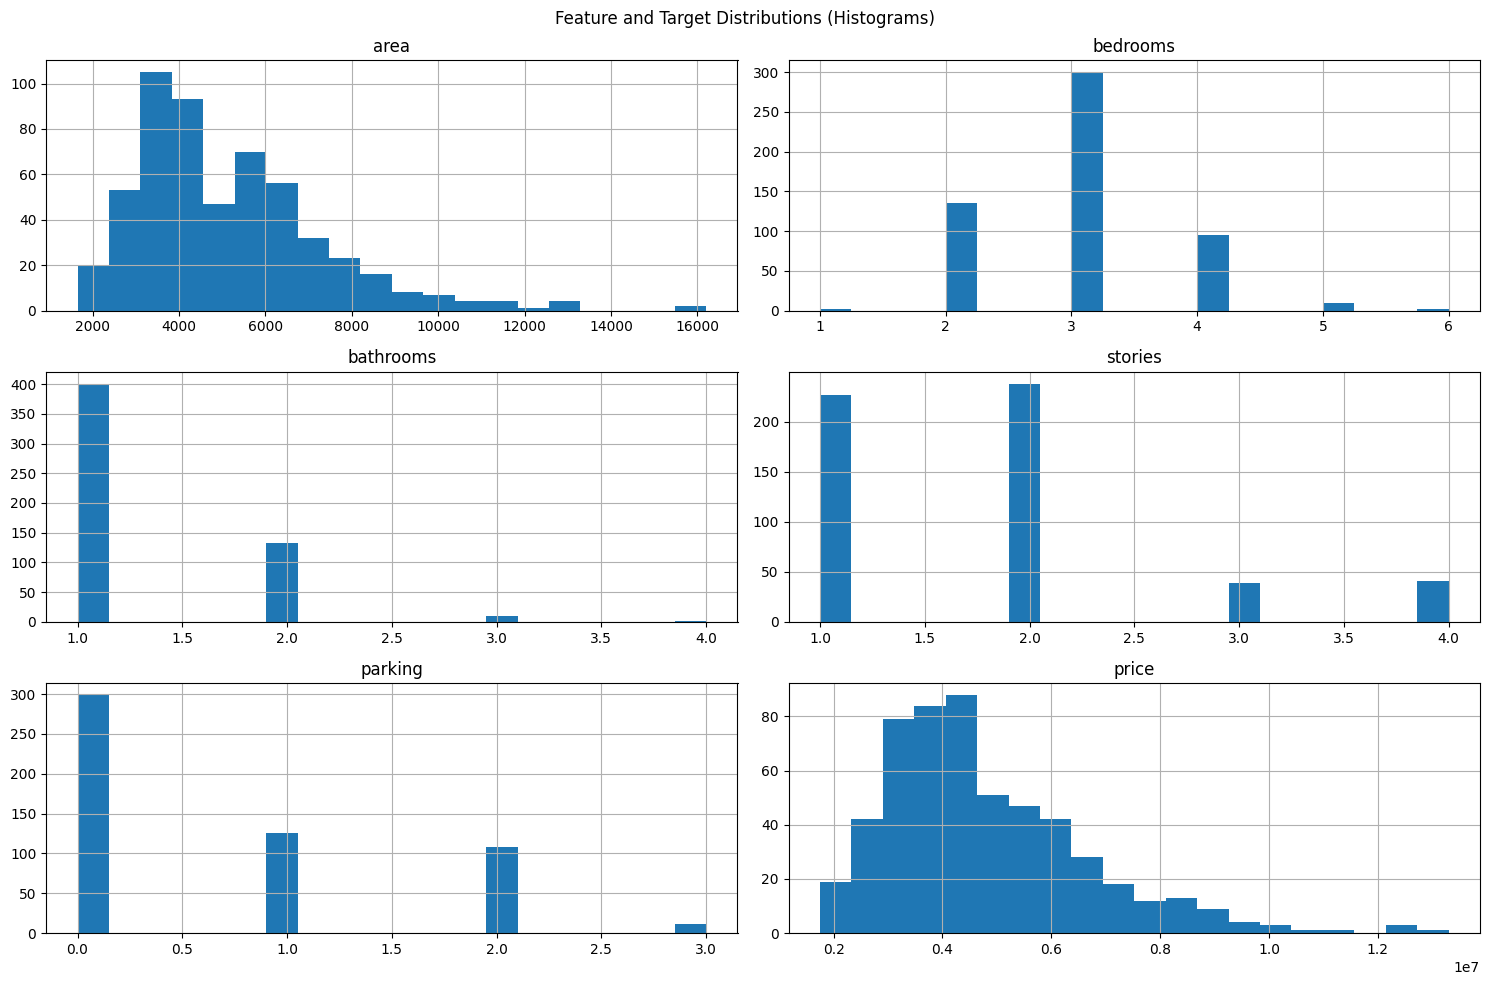

In [4]:
cols = df.columns.tolist()

df[cols].hist(bins=20, figsize=(15, 10))
plt.suptitle("Feature and Target Distributions (Histograms)")
plt.tight_layout()
plt.show()

This block creates histograms for each variable in the dataset. These plots help visualize how the values are distributed and whether some variables appear skewed or concentrated in certain ranges.

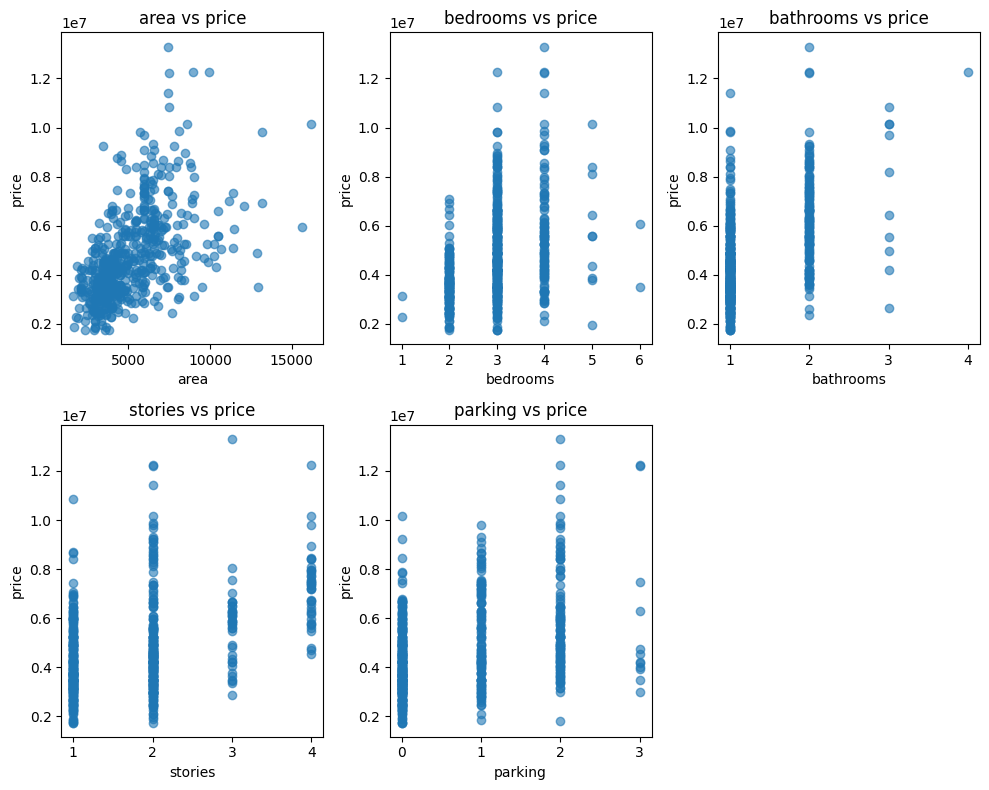

In [7]:
target = "price"
features = [c for c in df.columns if c != target]

plt.figure(figsize=(10, 8))
for i, feat in enumerate(features, 1):
    plt.subplot(2, 3, i)
    plt.scatter(df[feat], df[target], alpha=0.6)
    plt.title(f"{feat} vs {target}")
    plt.xlabel(feat)
    plt.ylabel(target)

plt.tight_layout()
plt.show()

This block creates scatterplots to compare each feature with the target variable, price. These visualizations help identify possible relationships between the predictors and house prices.

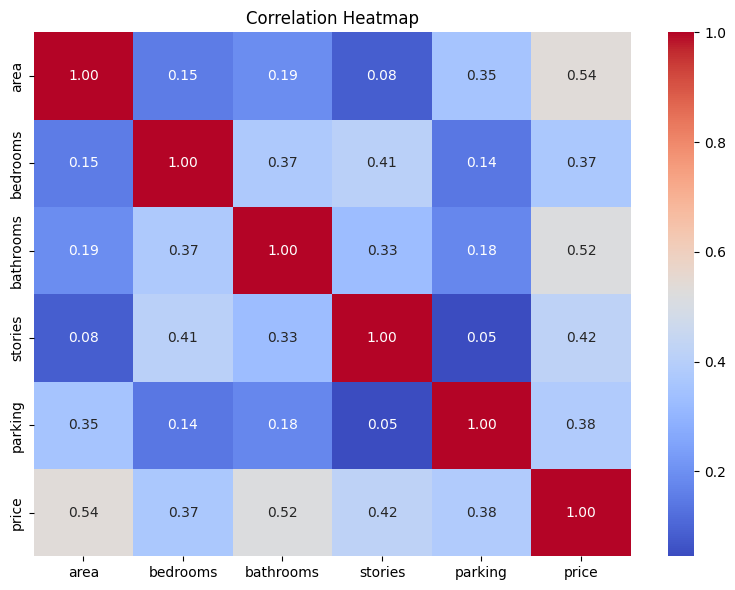

,area,bedrooms,bathrooms,stories,parking,price
area,1.000000,0.151858,0.193820,0.083996,0.352980,0.535997
bedrooms,0.151858,1.000000,0.373930,0.408564,0.139270,0.366494
bathrooms,0.193820,0.373930,1.000000,0.326165,0.177496,0.517545
stories,0.083996,0.408564,0.326165,1.000000,0.045547,0.420712
parking,0.352980,0.139270,0.177496,0.045547,1.000000,0.384394
price,0.535997,0.366494,0.517545,0.420712,0.384394,1.000000


In [8]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

corr

This block generates a correlation heatmap showing the relationships among the numerical variables. It helps identify which features appear more strongly associated with house price and with each other.

In [9]:
X = df[features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (436, 5)
Test shape: (109, 5)


This block separates the predictors from the target and splits the dataset into training and testing sets. The training data is used to fit the model, while the testing data is used to evaluate how well the model generalizes.

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (436, 5)
Scaled test shape: (109, 5)


This block applies feature scaling using StandardScaler. Scaling helps the deep neural network train more effectively by putting the input variables on a similar scale.

In [12]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

This block builds a feedforward deep neural network for regression. The hidden layers use the ReLU activation function to learn complex patterns, and the output layer contains one unit because the model is predicting a continuous value, house price.

In [13]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 25349389811712.0000 - mae: 4727422.0000 - val_loss: 24781594296320.0000 - val_mae: 4623896.5000
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 25349383520256.0000 - mae: 4727421.0000 - val_loss: 24781585907712.0000 - val_mae: 4623896.0000
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 25349373034496.0000 - mae: 4727420.5000 - val_loss: 24781575421952.0000 - val_mae: 4623895.0000
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 25349360451584.0000 - mae: 4727419.0000 - val_loss: 24781560741888.0000 - val_mae: 4623894.0000
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 25349343674368.0000 - mae: 4727417.0000 - val_loss: 24781539770368.0000 - val_mae: 4623891.5000
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 25349318508544.0000 - mae: 4727415.0000 - val_loss: 24781510410240.0000 - val_mae: 4623888.5000
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2534

This block trains the deep neural network using the scaled training data. The validation split allows the model’s performance to be monitored during training, helping compare training and validation behavior over time.

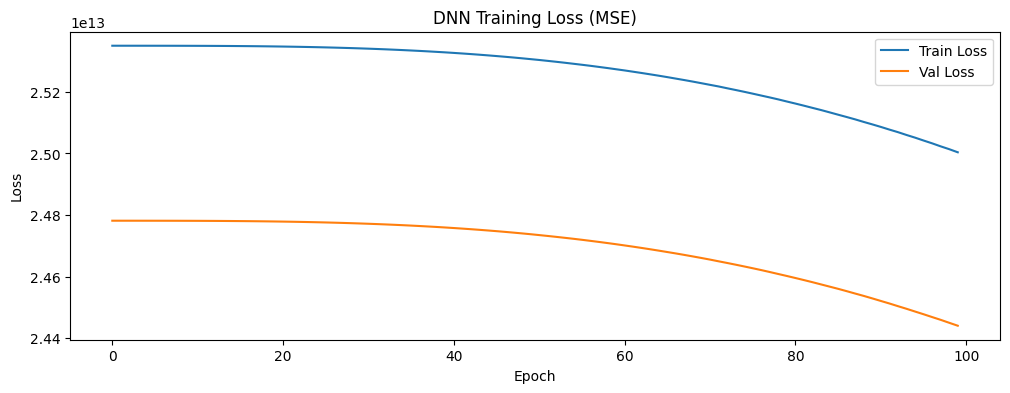

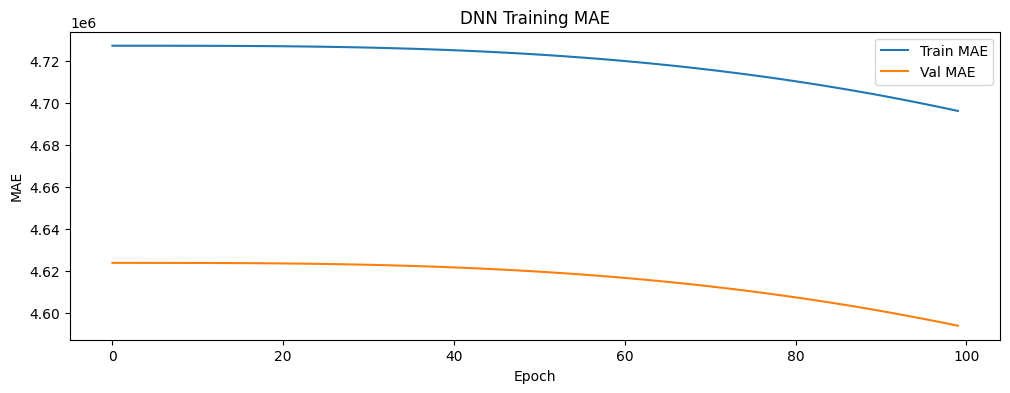

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("DNN Training Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.title("DNN Training MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

This block plots the training and validation loss as well as training and validation MAE. These plots help evaluate how the model learned over time and whether training and validation performance are behaving consistently.

In [15]:
for i, layer in enumerate(model.layers):
    weights = layer.get_weights()
    print(f"Layer {i+1} weights and biases:")
    print(weights)
    print("-" * 80)

Layer 1 weights and biases:
[array([[ 0.35704356,  1.743388  ,  1.8626429 ,  0.5075702 ,  2.1220906 ,
         2.0995095 ,  2.0245268 ,  0.9766398 ,  1.6693356 ,  1.9813626 ,
         1.8899077 ,  1.6964617 ,  1.8376654 ,  2.0762932 ,  1.7790192 ,
         1.8407212 ,  1.6455728 ,  1.7497005 ,  2.0030184 , -1.5110503 ,
        -0.74856704, -0.42636198,  2.0668762 ,  2.1254714 ,  1.5105387 ,
         2.1402757 ,  1.6029259 ,  2.0499427 ,  1.6146342 , -0.9120059 ,
         1.879664  ,  2.110599  ,  1.5610516 ,  2.1023195 ,  1.399248  ,
         1.1025242 , -0.02077958,  1.4257245 ,  1.6940268 ,  2.1187844 ,
         1.034115  , -0.4338163 ,  1.9121444 , -1.9267552 ,  1.942147  ,
         1.6497686 ,  0.9279463 ,  1.4594228 ,  1.8621844 , -1.4963775 ,
         1.4194343 ,  1.7217274 , -1.5135564 , -1.4927286 ,  1.1491189 ,
         1.629143  , -1.8447875 ,  1.9927642 ,  1.9022402 ,  2.0206158 ,
         1.83165   ,  2.1244507 ,  0.43460295,  1.9626658 ],
       [ 1.9653095 ,  2.1008716 , 

This block prints the learned weights and biases of each layer. These values represent the internal parameters the model adjusted during training in order to make better predictions.

In [16]:
y_pred = model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
MAE: 4973587.0
RMSE: 5451058.344951373
R²: -4.878647327423096


This block generates predictions on the test set and calculates evaluation metrics. MAE measures average prediction error, RMSE gives more weight to larger errors, and R² indicates how much of the variation in house prices is explained by the model.

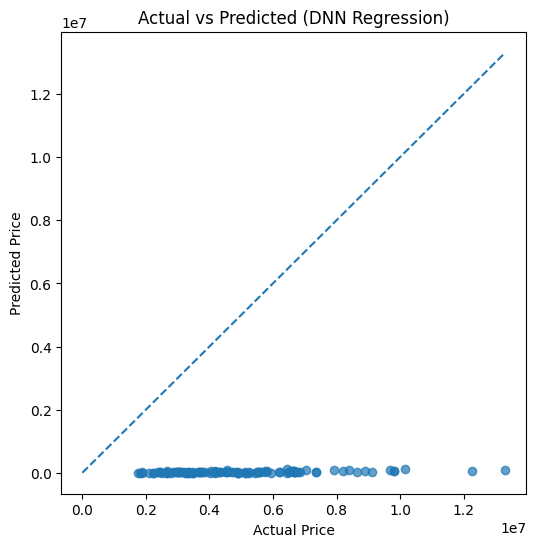

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.title("Actual vs Predicted (DNN Regression)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

This block creates a scatterplot comparing actual house prices with predicted house prices. Points closer to the diagonal reference line indicate better predictive performance.

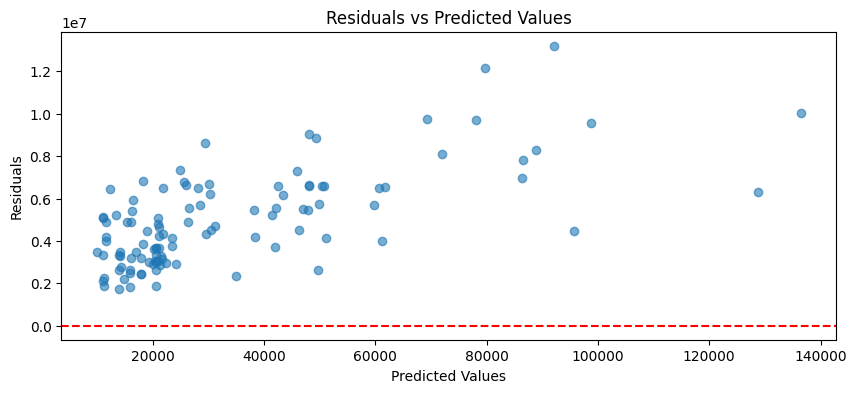

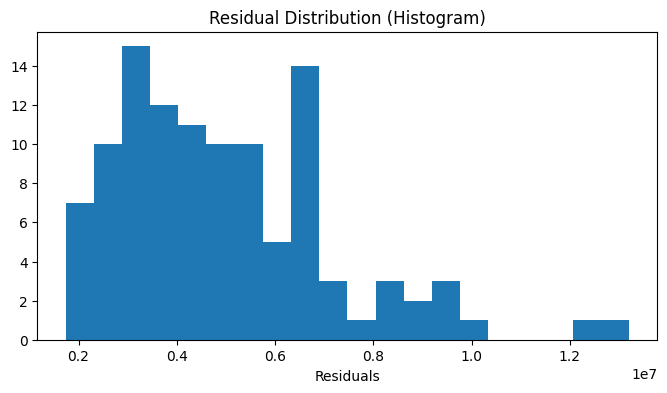

In [18]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", color="red")
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution (Histogram)")
plt.xlabel("Residuals")
plt.show()

This block visualizes the residuals, which are the differences between actual and predicted values. Residual plots help identify whether prediction errors are randomly distributed or whether systematic patterns remain.

### Summary of DNN Regression
- Imported libraries and loaded the Housing-1.csv dataset.
- Performed exploratory data analysis using histograms, scatterplots, and a correlation heatmap.
- Preprocessed the data by splitting it into training and testing sets and scaling the features.
- Built and trained a feedforward deep neural network for house price regression.
- Evaluated model performance using MAE, RMSE, and R².
- Visualized predictions and residuals to better understand model behavior.